# ❤️Heart Disease Prediction with XGBoost (AUC 0.93)

This notebook explores the **Heart Failure Clinical Records** dataset and builds a 
machine-learning model to predict whether a patient has **heart disease**.

We will:

1. Understand the dataset and clean it.
2. Explore how age, sex, chest pain, blood pressure, cholesterol, etc. relate to heart disease.
3. Build an XGBoost model with **5-fold cross-validation**.
4. Evaluate it using **AUC-ROC** and interpret the most important features.

---

In [2]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)



# import os
# for dirname, _, filenames in os.walk('../data/raw/heart.csv'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))


# 1.📈 Dataset Loading and Cleaning
### 📝Note: Since the dataset contain no null values, so skipping the cleaning part


In [4]:
dataset = pd.read_csv("../data/raw/heart.csv")

In [5]:
df = dataset.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [6]:
# df['HeartDisease'].value_counts()
print(df['HeartDisease'].value_counts(normalize=True))
## this is a balanced dataset having almost half of each values

HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64


# 2.ℹ️ Dataset Information
### Feature Description

| Column          | Description |
|----------------|-------------|
| `Age`          | Age of the patient (years) |
| `Sex`          | Sex of the patient (M,F) |
| `ChestPainType`| TA / ATA / NAP / ASY |
| `RestingBP`    | Resting blood pressure (mm Hg) |
| `Cholesterol`  | Serum cholesterol (mg/dl) |
| `FastingBS`    | 1 if fasting blood sugar > 120 mg/dl else 0 |
| `RestingECG`   | ECG result (Normal, ST, LVH) |
| `MaxHR`        | Maximum heart rate achieved |
| `ExerciseAngina` | Exercise-induced angina (Y,N) |
| `Oldpeak`      | ST depression induced by exercise |
| `ST_Slope`     | Slope of peak exercise ST segment (Up, Flat, Down) |
| `HeartDisease` | Target: 1 = heart disease, 0 = normal |


In [7]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# 3.📊 Exploratory Data Analysis
#### Finding insights, plotting different kinds of pattern and getting to know how the heart disease is caused by other variables

In [11]:
# Importing all the necessary libraries
import pandas as pd # data processing, CSV file I/O
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#one hot encoding
from sklearn.preprocessing import OneHotEncoder

#libraries for building the ML model
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier #classification model
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


## 3.1 Finding Unique values in each columns
### These are the unique values in each column. since its a categorical value, lets turn this into numerical. using one hot encoding

In [13]:
unique_values = {}
for column_name in df.columns:
    if df[column_name].dtype == 'object':
        unique_values[column_name] = df[column_name].unique()

# Print the results
for col, unique_vals in unique_values.items():
    print(f"Unique values in object column '{col}': {unique_vals}")

## 3.2 Encoding Categorical values

### Using one hot encoding instead of Label Encoding

In [17]:
cat_col=['Sex','ChestPainType','RestingECG','ExerciseAngina', 'ST_Slope']

encoder = OneHotEncoder(sparse_output=False)

# Fit and transform
encoded = encoder.fit_transform(df[cat_col])

# Create DataFrame from encoded output
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_col))

# Drop original categorical columns from main DataFrame
df = df.drop(columns=cat_col)

# Concatenate the encoded columns back
df = pd.concat([df, encoded_df], axis=1)

In [16]:
#df.head()

## 3.3 Correlation Matrix

### Checking the correalation matrix, most of the independent variable are correlated to each other. There is a multicolinearity problem arise. So its better to avoid using logistic regression or SVM. Instead we can go for the XGBoost, RandomForest or Decision Tree or KNN

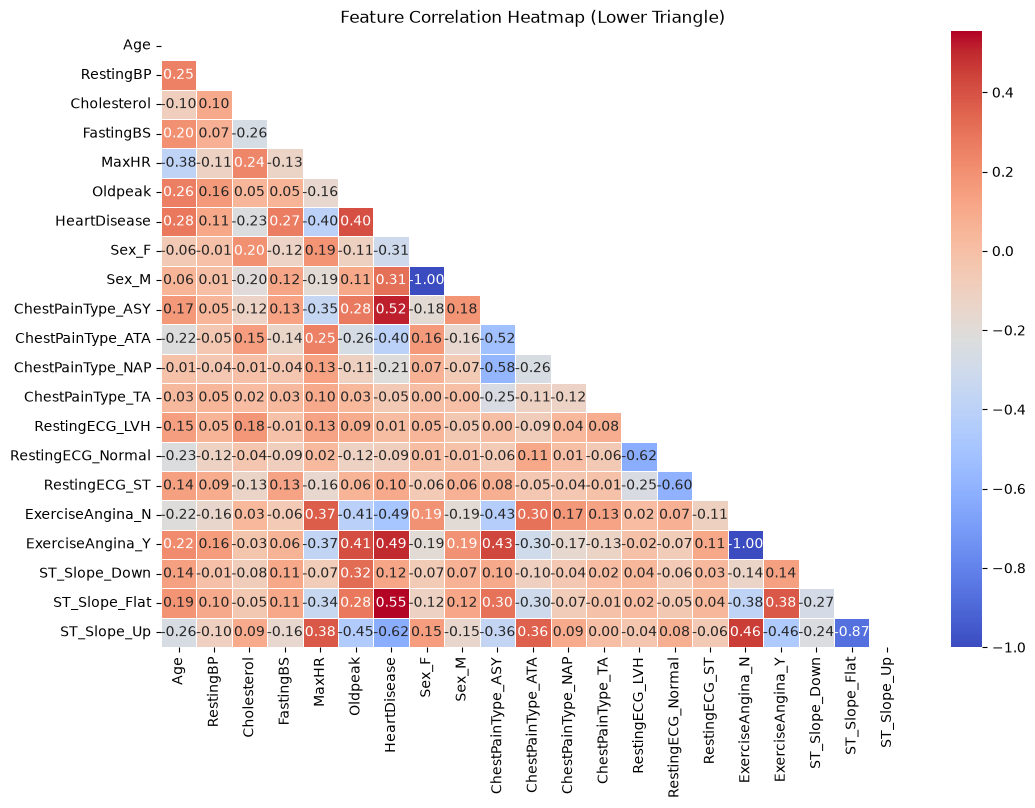

In [18]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12, 8))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap (Lower Triangle)")
plt.show()

In [19]:
df_eda = dataset.copy() #i took a copy of original dataset, since the one hot encoding is done perviously.
# its better to have some categorical values to plot some graphs.

## 3.4 Heart Disease Men vs Women ♀️♂️

### Male are mostly getting heart disease comparing to Women. Also the the count for no heart disease is also goes to male.

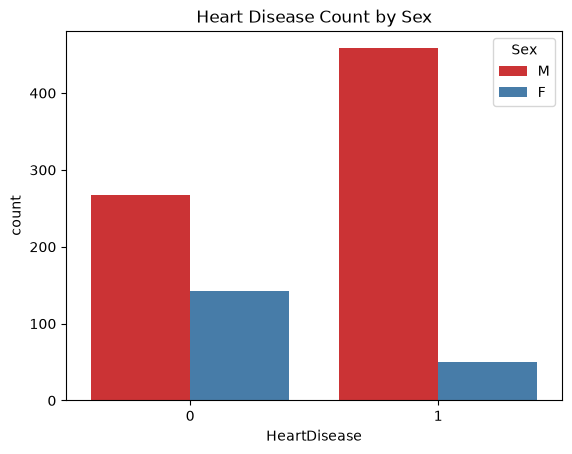

In [20]:
sns.countplot(data=df_eda, x='HeartDisease', hue='Sex', palette='Set1')
plt.title("Heart Disease Count by Sex")
plt.show()

## 3.5 Heart Disease Rate by Age Group & Sex

### The Graph itself is self exploratory. most of the patients tends to be Male. There are lot of outliers too. we can see a linear growth in male section for having heart diseases.

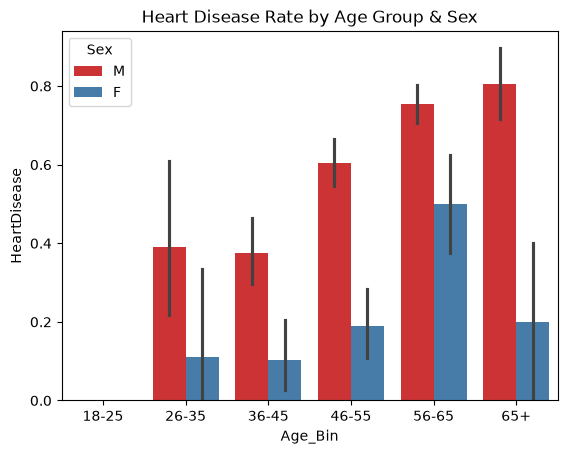

In [21]:
# Define bin boundaries
bins = [0, 25, 35, 45, 55, 65, 100]

# Define labels for each bin
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']

# Create Age_Bin column
df_eda['Age_Bin'] = pd.cut(df_eda['Age'], bins=bins, labels=labels)

sns.barplot(data=df_eda, x='Age_Bin', y='HeartDisease', hue='Sex', palette='Set1')
plt.title("Heart Disease Rate by Age Group & Sex")
plt.show()

## 3.6 Chest Pain causing heart disease for different gender
### from the graph it shows that the Asymptomatic chest pain cause the major hear disease related problem and mostly it occurs in male gender. and also with the help of previous example we can say the older aged men suffer from this chest pain condition.

Text(0.5, 1.0, 'Heart Disease Based on the Chestpain')

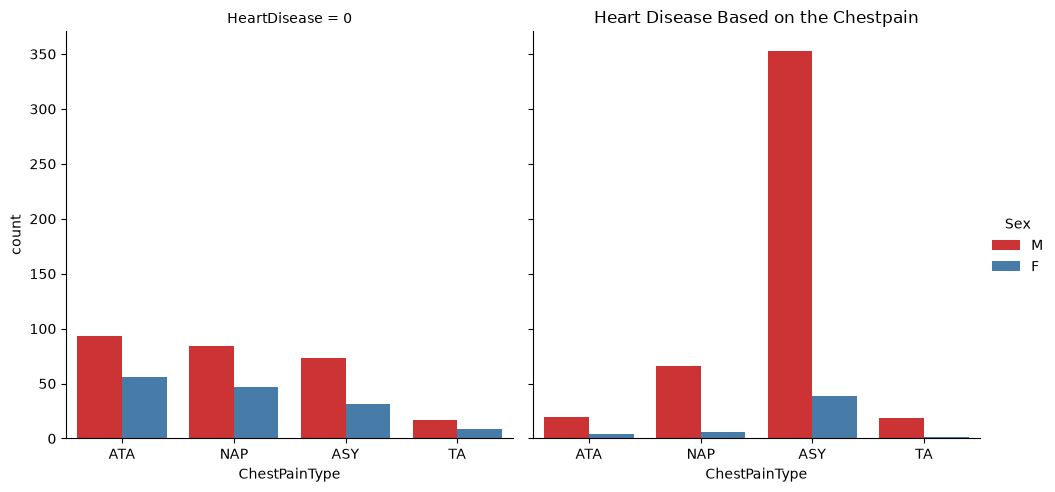

In [22]:
sns.catplot(
    data=df_eda,
    x='ChestPainType',
    hue='Sex',
    col='HeartDisease',
    kind='count',
    palette='Set1',
    height=5,
    aspect=1
)
plt.title("Heart Disease Based on the Chestpain")

In [23]:
#sns.violinplot(data=df_eda, y='MaxHR', x='HeartDisease')

## 3.7 Maximum Heart Rate(MaxHR) vs Heart Disease
#### from the plot its mean that the healthy heart can achieve a maximum heart rate when comparing to the unhealthy heart conditions. also the median heart rate is higher for  healthy heart where as compared to the other. Reduced maximum heart rate is strongly associated with heart disease, poor exercise capacity, and impaired cardiac function

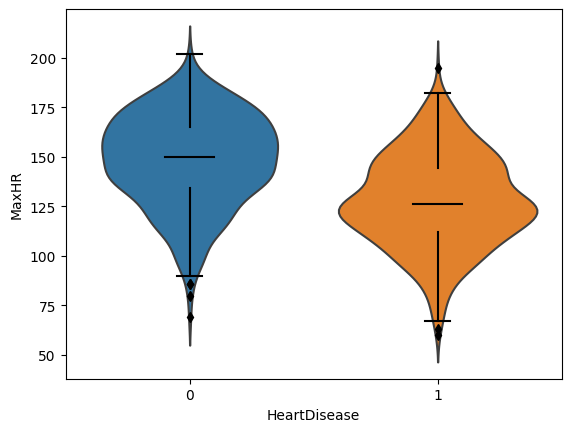

In [23]:
sns.violinplot(data=df_eda, x='HeartDisease', y='MaxHR', inner=None)
sns.boxplot(data=df_eda, x='HeartDisease', y='MaxHR', width=0.2, color='black')
plt.show()

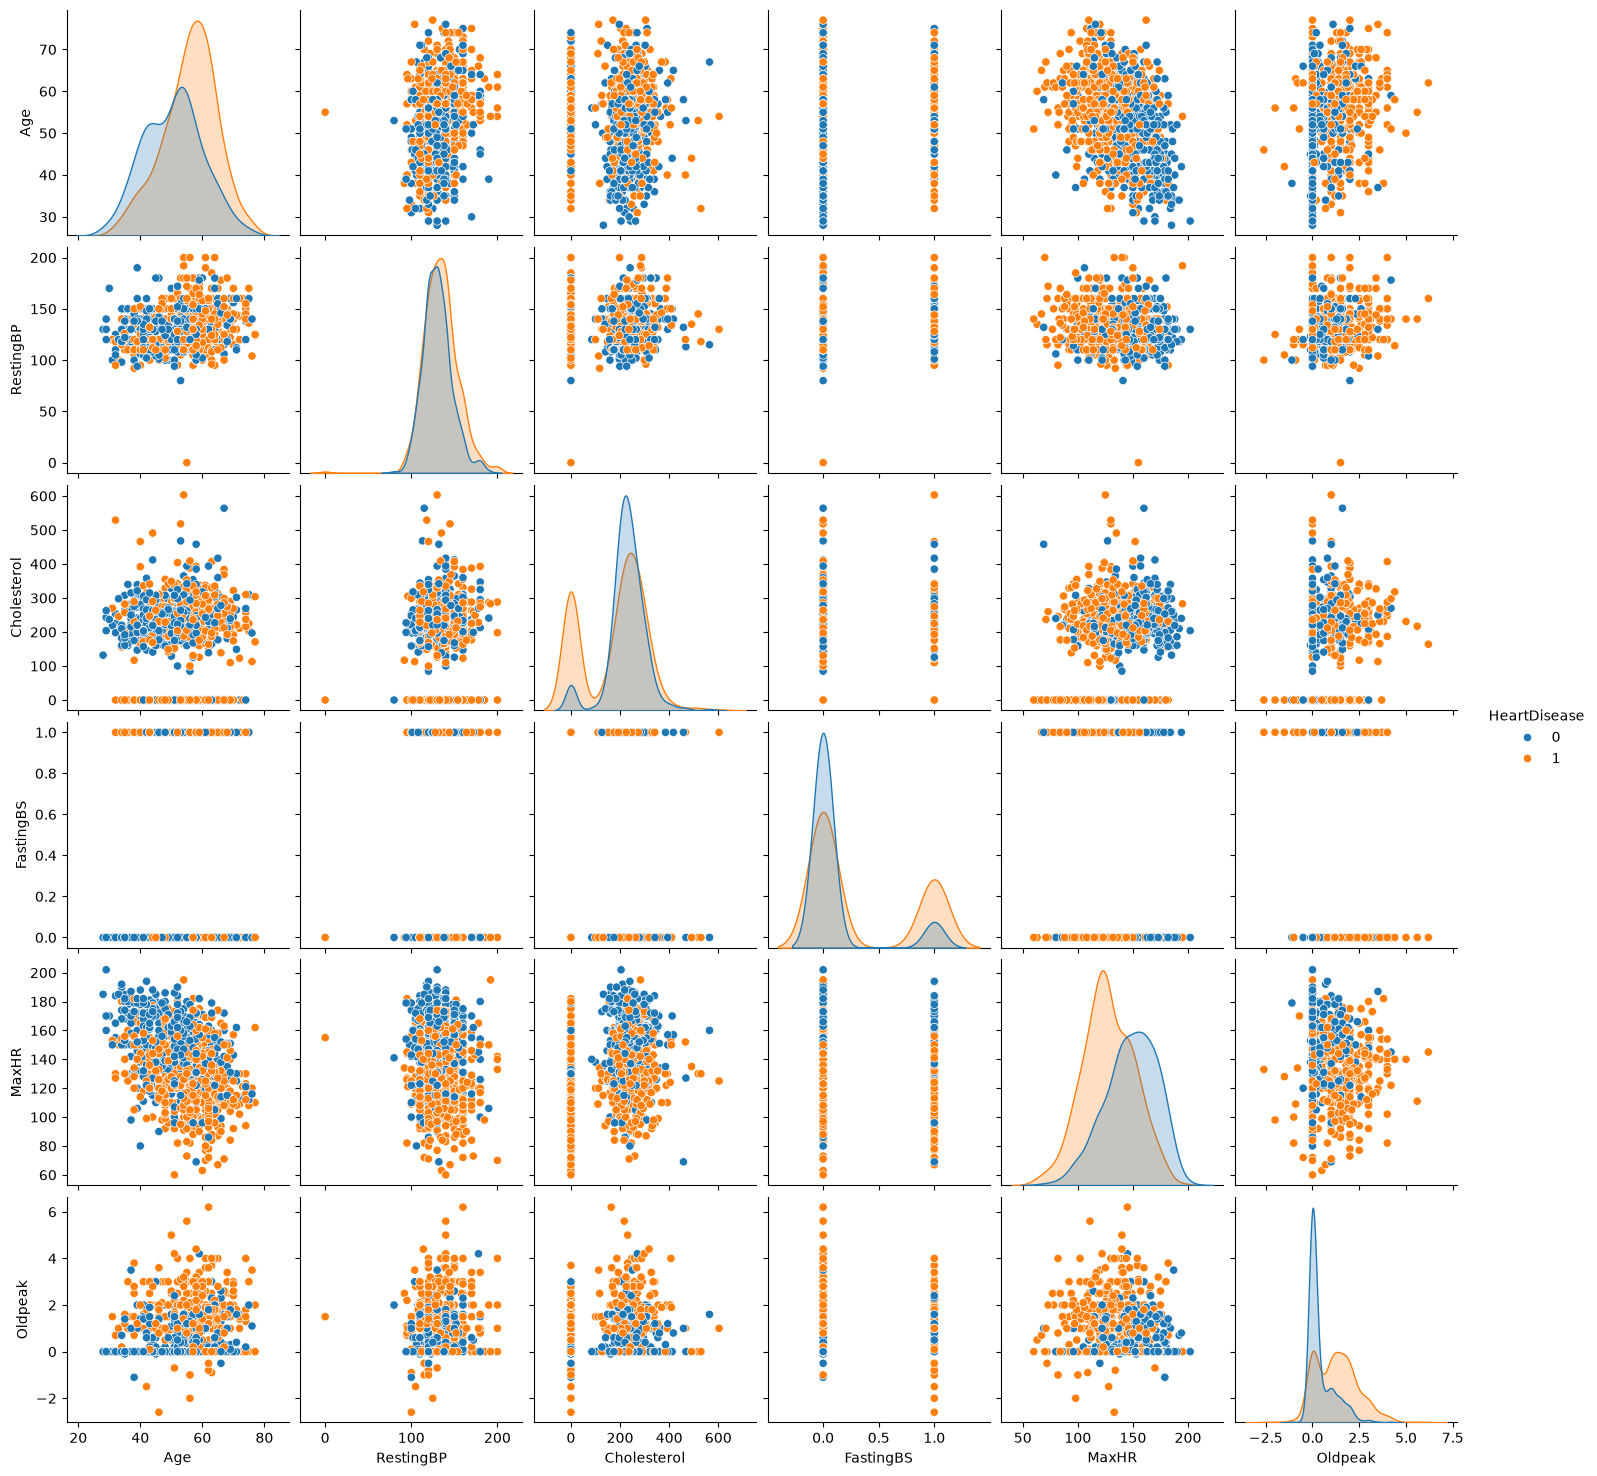

In [24]:
sns.pairplot(df_eda, hue='HeartDisease')

# 4. ML Model Predicting Possibliies of Heart Dieases

In [26]:
#df.info()
import shap

In [27]:
## Splitting the dataset into:
# X = input features (feature matrix)
# y = target label (HeartDisease) (target value)
X = df.drop(columns=['HeartDisease'], errors='ignore')
y = df['HeartDisease']

print("size of X and Y", len(X),len(y))

size of X and Y 918 918


## 4.1 Built the model and Training

In [29]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # I use the stratifiedKfold method

oof_predictions = np.zeros(len(X))  # preparing the storage for the off_prediction of size X here it is 918
print("size of off_prediction", len(oof_predictions))
fold_scores = []  #variable to store the each fold socres

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    #this lines gives the fold number, the row indexes for the training and row indexes for validation. thats the
    # reason why we use iloc for the data retrival, 
    print(f"Training fold {fold+1}...")

    # Enumerate : It gives us fold number Makes logs readable Helps analyze per-fold performance
    
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    print("shape of X_train and X_valid", len(X_train), len(X_valid))
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    print("shape of y_train and y_valid", len(y_train), len(y_valid))

    # Here the iloc is used to get the position based index for the train and validation set
    # Variable	What It Contains
    # X_train	training features
    # y_train	training true labels
    # X_valid	validation features
    # y_valid	validation true labels
    

    model = XGBClassifier(
        n_estimators=400,
        learning_rate=0.01,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.2,
        reg_alpha=0.3,
        reg_lambda=1.2,
        random_state=42,
        early_stopping_rounds=100,
        eval_metric="logloss"
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False,
        
    )
    print("Size of X_valid",X_valid.shape)
    
    # OutOffFold OOF preds (probability for class 1)
    val_pred = model.predict_proba(X_valid)[:,1]
    # print("size of val_pred", len(val_pred)) #think it is 184 first time
    #here the probaliliy of having heart disease is stored 
    #in the val_pred. The model.predict_proba(X_valid) which simply
    # predicts the probablity for having disease or not , for example [0.2,0.8]
    # also keep in mind that X_valid have multiple rows, and 2 columns, 
    # column 0 probablity of not having disease and column 1 is probablity of having disease.
    # so in other words it check for 184 rows (X_valid rows, and predict the probablity.) 
    #out of that only the column of 1st index is taken and stored in the val_pred
                                                
    
    #print(val_pred)
    oof_predictions[valid_idx] = val_pred # storing the val_pred to the off_prediction variable

    # Compute AUC for the fold
    fold_auc = roc_auc_score(y_valid, val_pred)
    fold_scores.append(fold_auc)
    print(f"Fold {fold+1} AUC: {fold_auc:.4f}")
# Overall AUC
print("\nOverall CV AUC:", roc_auc_score(y, oof_predictions))
print("Mean Fold AUC:", np.mean(fold_scores))

size of off_prediction 918
Training fold 1...
shape of X_train and X_valid 734 184
shape of y_train and y_valid 734 184
Size of X_valid (184, 20)
Fold 1 AUC: 0.9475
Training fold 2...
shape of X_train and X_valid 734 184
shape of y_train and y_valid 734 184
Size of X_valid (184, 20)
Fold 2 AUC: 0.9446
Training fold 3...
shape of X_train and X_valid 734 184
shape of y_train and y_valid 734 184
Size of X_valid (184, 20)
Fold 3 AUC: 0.8922
Training fold 4...
shape of X_train and X_valid 735 183
shape of y_train and y_valid 735 183
Size of X_valid (183, 20)
Fold 4 AUC: 0.9516
Training fold 5...
shape of X_train and X_valid 735 183
shape of y_train and y_valid 735 183
Size of X_valid (183, 20)
Fold 5 AUC: 0.9209

Overall CV AUC: 0.9300989053197618
Mean Fold AUC: 0.9313616584040039


## 4.3 ROC - AUC curve

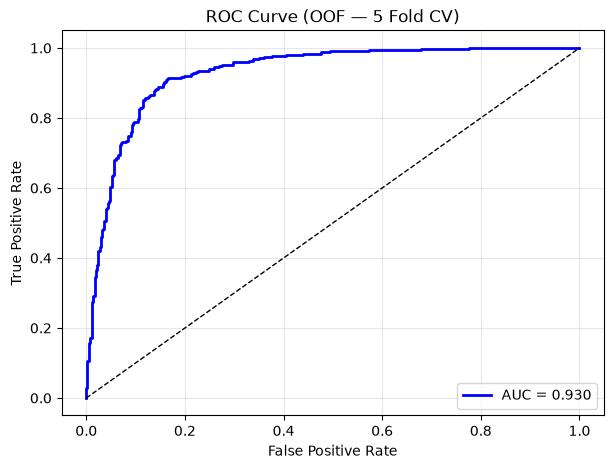

In [30]:
# ROC using full OOF predictions
fpr, tpr, _ = roc_curve(y, oof_predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', label=f"AUC = {roc_auc:.3f}", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)   # diagonal line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (OOF — 5 Fold CV)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig('ROC Curve.png')
plt.show()


In [31]:
train_pred = model.predict_proba(X_train)[:, 1]
train_auc = roc_auc_score(y_train, train_pred)
val_auc = roc_auc_score(y_valid, val_pred)

print(f"Fold {fold+1} Train AUC: {train_auc:.4f}, Val AUC: {val_auc:.4f}")

Fold 5 Train AUC: 0.9778, Val AUC: 0.9209


## 4.4 Confusion Matrix

#### from the confusion matrix we can say that the model is predicting the target value better.

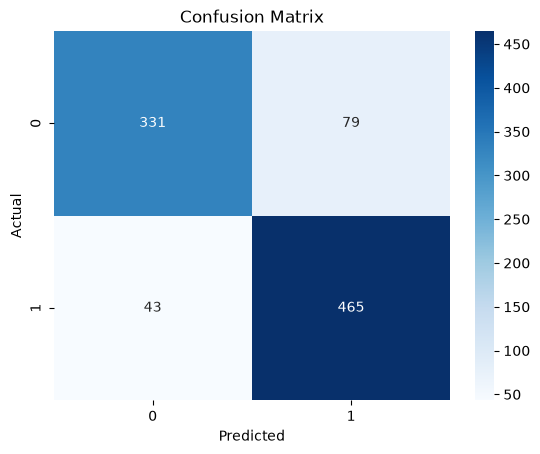

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

threshold = 0.45
# Get predicted classes from your final model
y_pred_class = (oof_predictions > threshold).astype(int)  # set the threshold to 0.5

cm = confusion_matrix(y, y_pred_class)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig('Confusion Matrix.png')
plt.show()


## 4.5 Accuracy Precision Recall F1score

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
threshold = 0.48
y_pred_class = (oof_predictions > threshold).astype(int)

print("Accuracy:", accuracy_score(y, y_pred_class))
print("Precision:", precision_score(y, y_pred_class))
print("Recall:", recall_score(y, y_pred_class))
print("\nClassification Report:\n", classification_report(y, y_pred_class))

## Here i check the checking performance on the entire dataset using cross-validated predictions (OOF).
# It is NOT per-fold.
# It is overall CV performance.

Accuracy: 0.8758169934640523
Precision: 0.8675373134328358
Recall: 0.9153543307086615

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.83      0.86       410
           1       0.87      0.92      0.89       508

    accuracy                           0.88       918
   macro avg       0.88      0.87      0.87       918
weighted avg       0.88      0.88      0.88       918



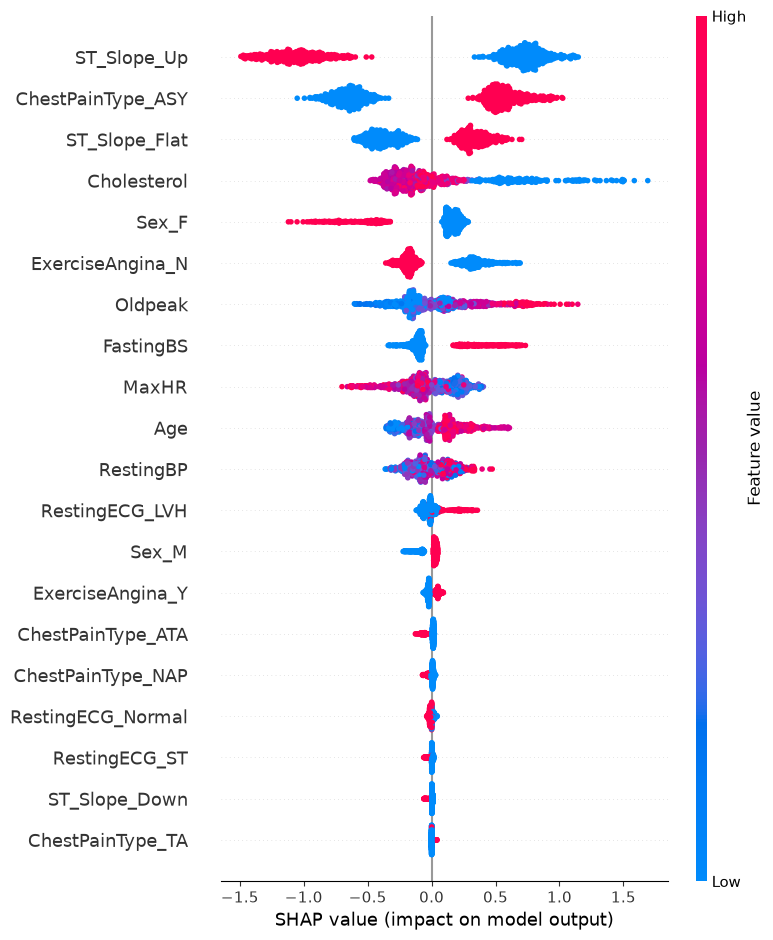

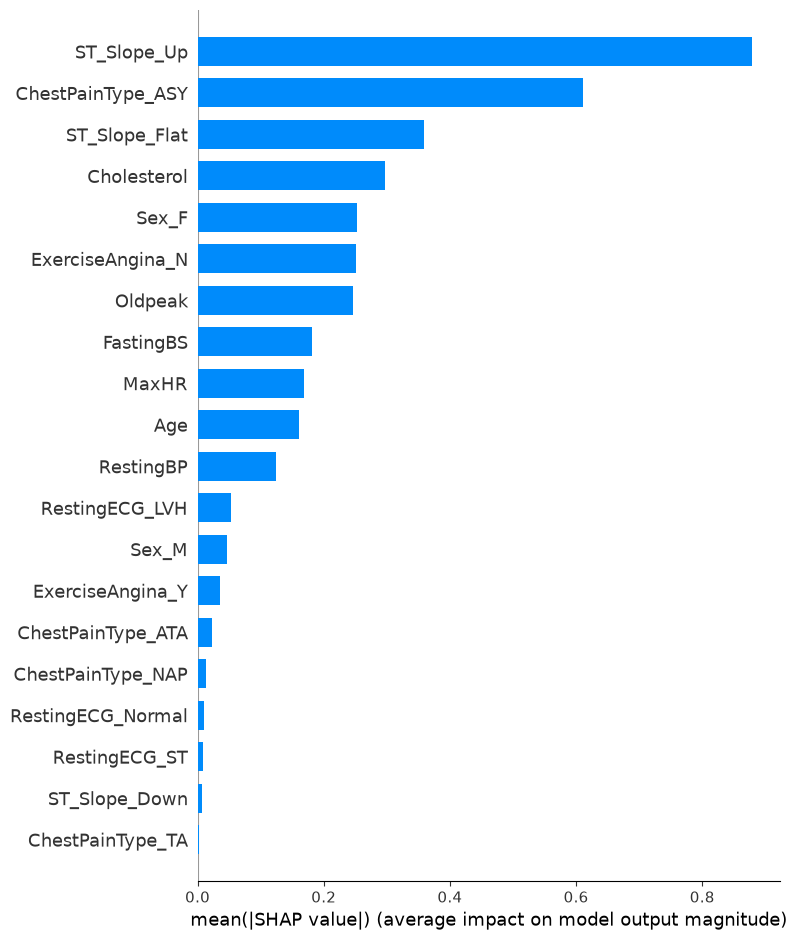

In [34]:
from xgboost import XGBClassifier

final_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.2,
    reg_alpha=0.3,
    reg_lambda=1.2,
    random_state=42,
    eval_metric="logloss"
)

final_model.fit(X, y)

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

# Summary plot
shap.summary_plot(shap_values, X)

# Bar plot for feature importance
shap.summary_plot(shap_values, X, plot_type="bar")

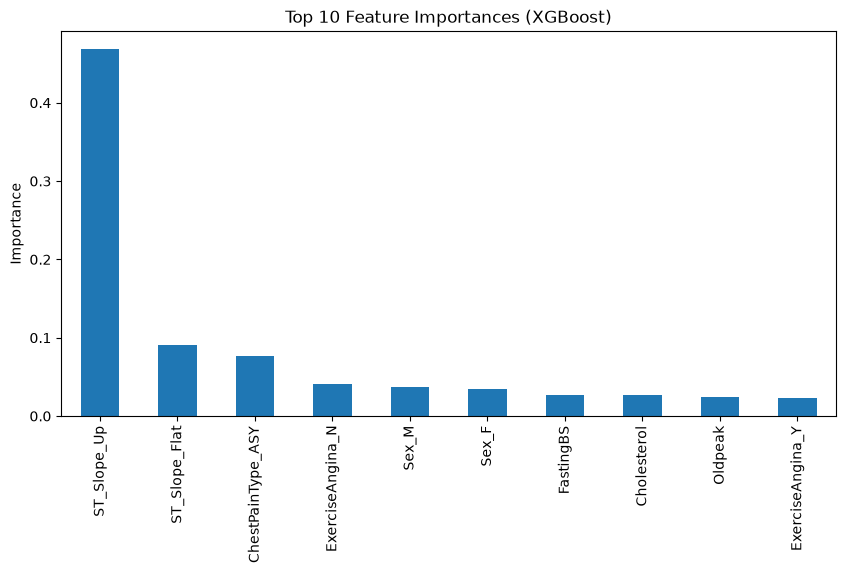

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

importances = final_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,5))
feat_imp.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances (XGBoost)")
plt.ylabel("Importance")
plt.show()

## 4.6 Threshold Analysis

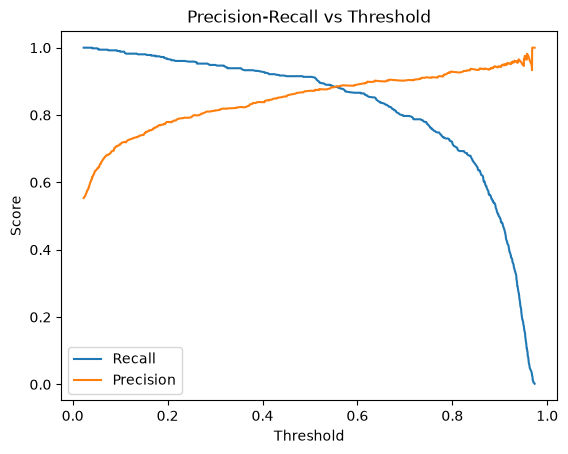

In [36]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y, oof_predictions)

plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.legend()
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.savefig('Threshold Value.png')
plt.show()


#### The precision-recall trade-off demonstrates that lowering the decision threshold increases recall at the cost of precision. For clinical risk screening, a lower threshold may be preferred to minimize false negatives, whereas a higher threshold may be suitable when reducing false positives is critical.

## 5. Final Note 
### Model Review

#### The model achieved a cross-validated ROC-AUC of 0.93, demonstrating strong ability to rank patients by cardiovascular risk. Trade-off analysis was performed to balance recall and precision depending on clinical use case.

#### Here we use K fold technique and XGboost Classification alogirthm. We analyse all the possibilities of overfitting and underfitting. Since the dataset is small. its possible to underfit or overfit. We eliminate both of them. We confirm by checking the ROC curve. Then used Confusion matrix to confirm it.
#### The Model perform well and not overfit or underfit.

#### The model predict pretty well and can be used to predict the target value by feeding the unkown feature variable into the model

### 🙏 Thank you for your support!  
I appreciate your time — comments and suggestions are always welcome.
